In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
%matplotlib inline

In [2]:
columns = [f"A{i}" for i in range(1, 16)] + ["Class"]

df = pd.read_csv(
    "crx.data",
    header=None,
    names=columns,
    na_values="?"
)
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,Class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [3]:
print("Розмір датасету:", df.shape)
df.info()

Розмір датасету: (690, 16)
<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    str    
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    str    
 4   A5      684 non-null    str    
 5   A6      681 non-null    str    
 6   A7      681 non-null    str    
 7   A8      690 non-null    float64
 8   A9      690 non-null    str    
 9   A10     690 non-null    str    
 10  A11     690 non-null    int64  
 11  A12     690 non-null    str    
 12  A13     690 non-null    str    
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  Class   690 non-null    str    
dtypes: float64(4), int64(2), str(10)
memory usage: 86.4 KB


In [4]:
df = df.replace("?", np.nan)
print("Кількість пропусків у кожній колонці:")
df.isna().sum()

Кількість пропусків у кожній колонці:


A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64

In [5]:
numeric_cols = ["A2", "A3", "A8", "A11", "A14", "A15"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

categorical_cols = [col for col in df.columns if col not in numeric_cols + ["Class"]]
print("Числові колонки:", numeric_cols)
print("Категоріальні колонки:", categorical_cols)
df.dtypes

Числові колонки: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Категоріальні колонки: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


A1           str
A2       float64
A3       float64
A4           str
A5           str
A6           str
A7           str
A8       float64
A9           str
A10          str
A11        int64
A12          str
A13          str
A14      float64
A15        int64
Class        str
dtype: object

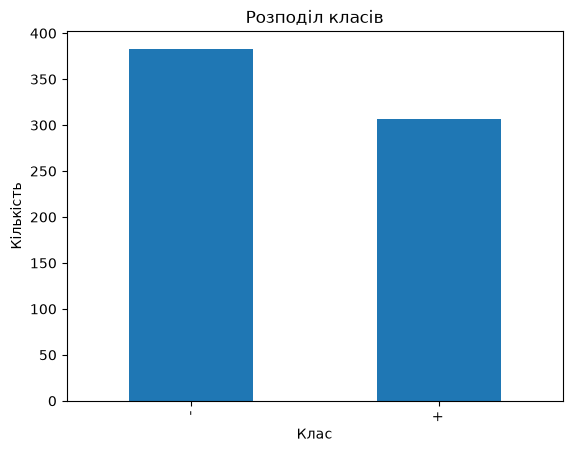

Class
-    0.555072
+    0.444928
Name: proportion, dtype: float64

In [6]:
df["Class"].value_counts().plot(kind="bar")
plt.title("Розподіл класів")
plt.xlabel("Клас")
plt.ylabel("Кількість")
plt.show()
df["Class"].value_counts(normalize=True)

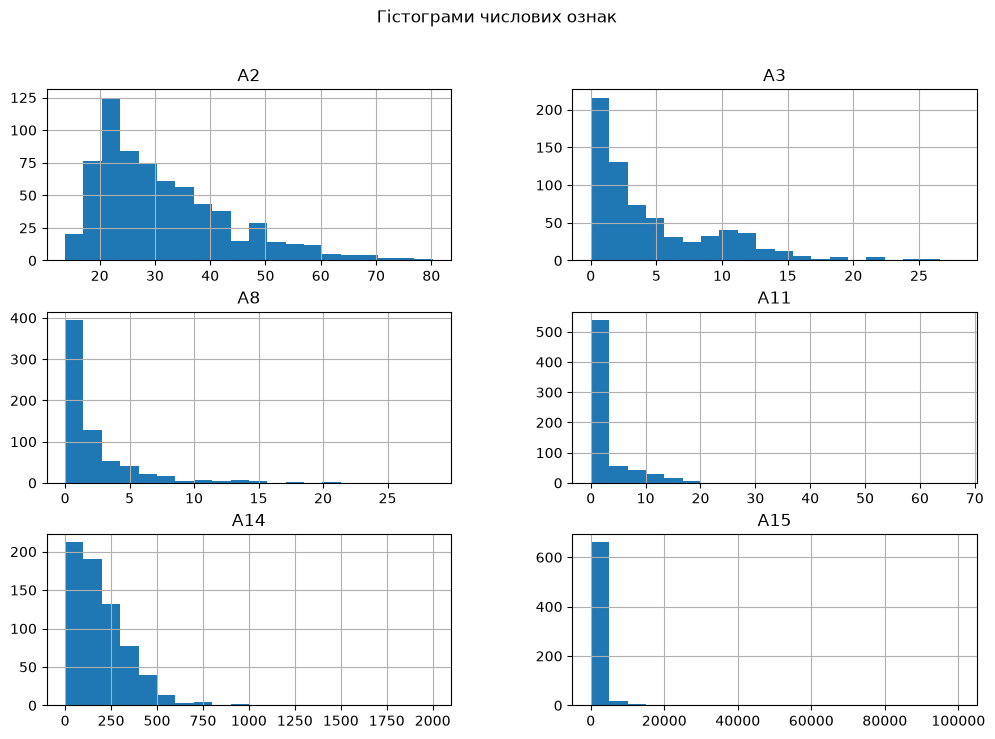

In [7]:
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Гістограми числових ознак")
plt.show()

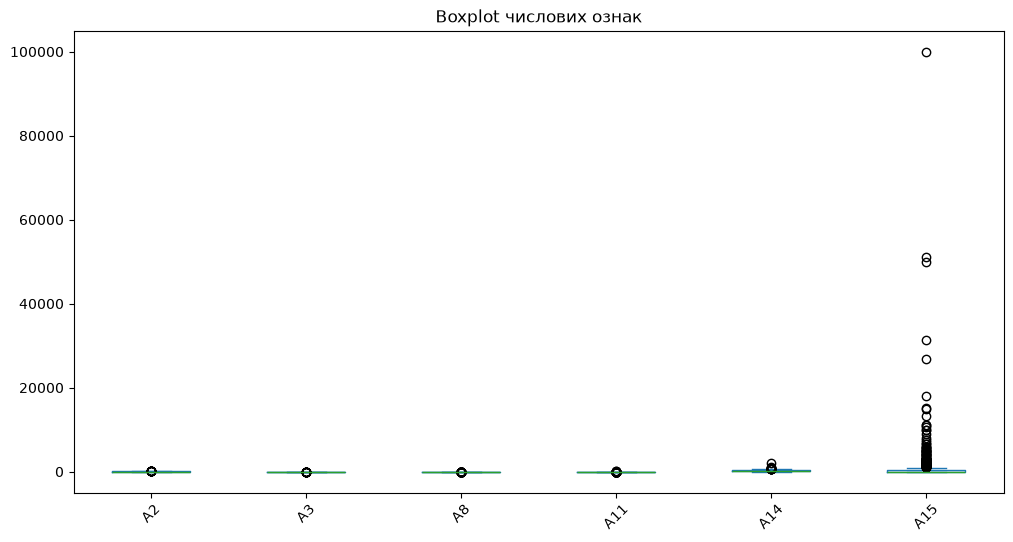

In [8]:
df[numeric_cols].plot(kind="box", figsize=(12, 6))
plt.title("Boxplot числових ознак")
plt.xticks(rotation=45)
plt.show()

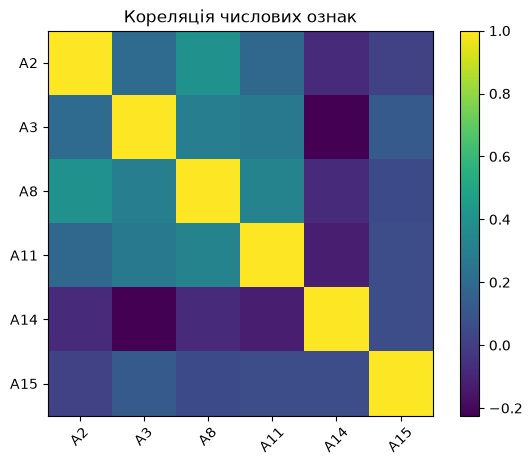

,A2,A3,A8,A11,A14,A15
A2,1.000000,0.202317,0.395751,0.185912,-0.079812,0.018553
A3,0.202317,1.000000,0.298902,0.271207,-0.224242,0.123121
A8,0.395751,0.298902,1.000000,0.322330,-0.077163,0.051345
A11,0.185912,0.271207,0.322330,1.000000,-0.120096,0.063692
A14,-0.079812,-0.224242,-0.077163,-0.120096,1.000000,0.066853
A15,0.018553,0.123121,0.051345,0.063692,0.066853,1.000000


In [9]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Кореляція числових ознак")
plt.show()

corr

In [10]:
df_fe = df.copy()
df_fe["num_sum"] = df_fe[numeric_cols].sum(axis=1)
df_fe["num_mean"] = df_fe[numeric_cols].mean(axis=1)
df_fe["A3_A8_ratio"] = df_fe["A3"] / (df_fe["A8"] + 0.001)
df_fe["A8_A11_interaction"] = df_fe["A8"] * df_fe["A11"]
df_fe["A2_bin"] = pd.cut(
    df_fe["A2"],
    bins=[0, 25, 40, 60, 100],
    labels=["young", "adult", "middle", "older"]
)
df_fe.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A12,A13,A14,A15,Class,num_sum,num_mean,A3_A8_ratio,A8_A11_interaction,A2_bin
0,b,30.83,0.000,u,g,w,v,1.25,t,t,...,f,g,202.0,0,+,235.080,39.180000,0.000000,1.25,adult
1,a,58.67,4.460,u,g,q,h,3.04,t,t,...,f,g,43.0,560,+,675.170,112.528333,1.466623,18.24,middle
2,a,24.50,0.500,u,g,q,h,1.50,t,f,...,f,g,280.0,824,+,1130.500,188.416667,0.333111,0.00,young
3,b,27.83,1.540,u,g,w,v,3.75,t,t,...,t,g,100.0,3,+,141.120,23.520000,0.410557,18.75,adult
4,b,20.17,5.625,u,g,w,v,1.71,t,f,...,f,s,120.0,0,+,147.505,24.584167,3.287551,0.00,young


In [11]:
X = df_fe.drop("Class", axis=1)
y = df_fe["Class"].map({"+": 1, "-": 0})

print(X.shape)
print(y.value_counts())

(690, 20)
Class
0    383
1    307
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (552, 20)
Test: (138, 20)


In [13]:
new_numeric_cols = numeric_cols + ["num_sum", "num_mean", "A3_A8_ratio", "A8_A11_interaction"]
new_categorical_cols = [col for col in X.columns if col not in new_numeric_cols]

print("Numerical:", new_numeric_cols)
print("Categorical:", new_categorical_cols)

Numerical: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'num_sum', 'num_mean', 'A3_A8_ratio', 'A8_A11_interaction']
Categorical: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A2_bin']


In [14]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), new_numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), new_categorical_cols)
    ]
)

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), new_numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), new_categorical_cols)
    ]
)

In [16]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

    print("Model:", model_name)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    return results

In [17]:
tree_model = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_model.fit(X_train, y_train)
tree_results = evaluate_model(tree_model, X_test, y_test, "Decision Tree")

Model: Decision Tree
Confusion matrix:
[[69  8]
 [ 8 53]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        77
           1       0.87      0.87      0.87        61

    accuracy                           0.88       138
   macro avg       0.88      0.88      0.88       138
weighted avg       0.88      0.88      0.88       138



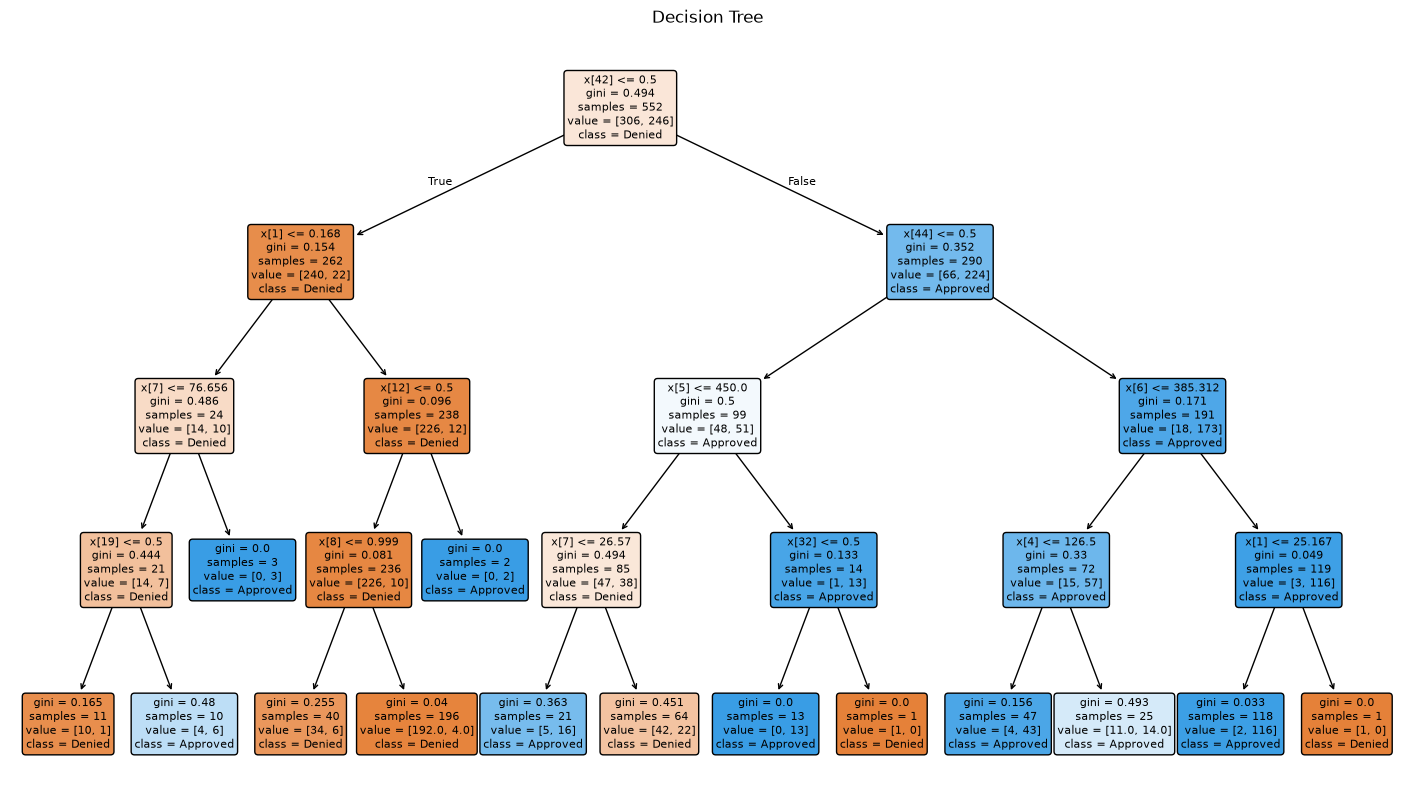

In [18]:
plt.figure(figsize=(18, 10))
plot_tree(
    tree_model.named_steps["classifier"],
    filled=True,
    rounded=True,
    class_names=["Denied", "Approved"],
    fontsize=8
)
plt.title("Decision Tree")
plt.show()

In [19]:
log_model = Pipeline(steps=[
    ("preprocessor", scaled_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)
log_results = evaluate_model(log_model, X_test, y_test, "Logistic Regression")

Model: Logistic Regression
Confusion matrix:
[[67 10]
 [10 51]]

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        77
           1       0.84      0.84      0.84        61

    accuracy                           0.86       138
   macro avg       0.85      0.85      0.85       138
weighted avg       0.86      0.86      0.86       138



In [20]:
knn_model = Pipeline(steps=[
    ("preprocessor", scaled_preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
knn_results = evaluate_model(knn_model, X_test, y_test, "KNN")

Model: KNN
Confusion matrix:
[[68  9]
 [16 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.83      0.74      0.78        61

    accuracy                           0.82       138
   macro avg       0.82      0.81      0.81       138
weighted avg       0.82      0.82      0.82       138



In [21]:
results_df = pd.DataFrame([tree_results, log_results, knn_results])
results_df

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.884058,0.868852,0.868852,0.868852
1,Logistic Regression,0.855072,0.836066,0.836066,0.836066
2,KNN,0.818841,0.833333,0.737705,0.782609


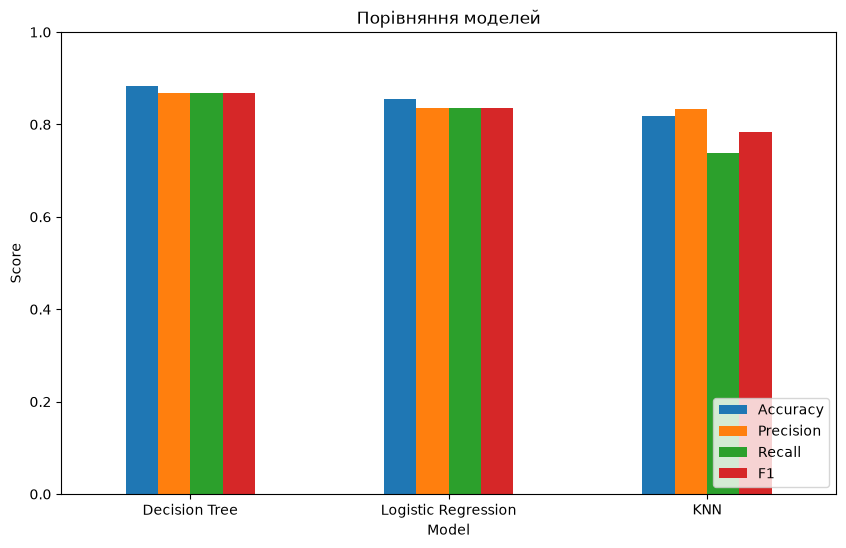

In [22]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", figsize=(10, 6))
plt.title("Порівняння моделей")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()